# Unified CEBRA encoders for integrating neural recordings via behavioral alignment

By Célia Benquet, Hossein Mirzaei, Steffen Schneider, & Mackenzie Weygandt Mathis

This is a demo notebook to run our proposed unified CEBRA encoder.
It uses the open-source rat hippocampus navigation dataset presented in the manuscript ([Grosmark & Buzáki, Science, 2016](https://www.science.org/doi/full/10.1126/science.aad1935)).

**ABSTRACT:** Analyzing neural activity across diverse recording sessions with varying neuron counts remains a challenge. We address this with a unified encoder model building on recent advances in contrastive learning. Our approach aligns neural data from different sessions by matching shared auxiliary labels at specific time points. This can be more strongly supervised with a behaviorally-based hypothesis, or weakly supervised with a general label, such as trial timing or another fiduciary label. This method effectively handles datasets with limited neuron counts and leverages pooled data to produce a high-performance unified encoder that can be used to study neural representations or in downstream tasks, such as decoding. Crucially, unified CEBRA is computationally efficient and fast to train, requiring fewer resources than large-scale alternatives, providing a practical tool for analyzing population-level neural computations across diverse experiments. We demonstrate its utility for extracting unified latents during motor control in monkeys and mice, navigation in rats, and during mice watching a naturalistic film.

In [1]:
!pip install -q --pre 'cebra[datasets,demos,integrations]'

Full execution of this notebook can take ~30min depending on your hardware. If you would like to load a reference run, set the `USE_CACHED_MODEL` variable to `True` to download [data from a reference run](https://figshare.com/ndownloader/articles/29275358?private_link=ae8099185f5e2f5e8185) which will allow you to render all plots. Set to `False` if the model and decoding should be re-run.

In [2]:
USE_CACHED_MODEL = True

# Set up package imports and load the demo data

In [3]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap, BoundaryNorm
import os
import seaborn as sns
import sklearn.metrics
import torch
import numpy as np

import cebra
from cebra.integrations.plotly import plot_embedding_interactive
from plotly.subplots import make_subplots

device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
# Load the datasets
hippocampus_a = cebra.datasets.init('rat-hippocampus-single-achilles')
hippocampus_b = cebra.datasets.init('rat-hippocampus-single-buddy')
hippocampus_c = cebra.datasets.init('rat-hippocampus-single-cicero')
hippocampus_g = cebra.datasets.init('rat-hippocampus-single-gatsby')

datasets = [hippocampus_a, hippocampus_b, hippocampus_c, hippocampus_g]

/Users/helmholtz/miniconda3/envs/cebra-demos-quick/lib/python3.10/site-packages/cebra/__init__.py:118: UserWarning: Your code triggered a lazy import of cebra.datasets. While this will (likely) work, it is recommended to add an explicit import statement to you code instead. To disable this warning, you can run ``cebra.allow_lazy_imports()``.
  warnings.warn(


In [5]:
# Download the cached model
if USE_CACHED_MODEL:
    print("Downloading cached model. If you want to re-run, set USE_CACHED_MODEL to False.")
    import os, requests, zipfile, shutil
    model_path = os.path.join("model", "250609-unified-reference-run.pt")
    if not os.path.exists(model_path):
        url = "https://figshare.com/ndownloader/articles/29275358?private_link=ae8099185f5e2f5e8185"
        with open("data.tgz", "wb") as f: f.write(requests.get(url).content)
        with zipfile.ZipFile("data.tgz", "r") as zip_ref: zip_ref.extractall()
        os.makedirs("model", exist_ok=True)
        shutil.move("250609-unified-reference-run.pt", "model")
        if os.path.exists("data.tgz"): os.remove("data.tgz")

In [6]:
# Split data and labels (labels we use later!)
train_data, valid_data = [], []
train_continuous_label, valid_continuous_label = [], []
for i, dataset in enumerate(datasets):
    split_idx = int(0.8 * len(dataset.neural)) #suggest: 5%-20% depending on your dataset size

    train_data.append(dataset.neural[:split_idx])
    valid_data.append(dataset.neural[split_idx:])

    train_continuous_label.append(dataset.continuous_index.numpy()[:split_idx])
    valid_continuous_label.append(dataset.continuous_index.numpy()[split_idx:])

train_datasets = [
    cebra.data.TensorDataset(
        neural=train_data[i], continuous=train_continuous_label[i], device=device
    )
    for i in range(len(train_data))
]

valid_datasets = [
    cebra.data.TensorDataset(valid_data[i], continuous=valid_continuous_label[i], device=device)
    for i in range(len(valid_data))
]

In [7]:
# Hyperparameters:
config = {"model_architecture": "offset10-model",
    "batch_size": 2048,
    "output_dimension": 32,
    "time_offsets": 10,
    "learning_rate": 0.0003,
    "num_hidden_units": 32,
    "temperature": 1,
    "max_iterations": 5000,
    "conditional": "time_delta",
    "verbose": True,
}

### Train model using the torch API

In [8]:
# Number of neurons = sum of neurons in all datasets
num_neurons = 0
for dataset in train_datasets:
    num_neurons += dataset.neural.shape[1]

# Define the dataset
dataset = cebra.data.UnifiedDataset(dataset for dataset in train_datasets)

# Set the masks for the dataset
# 'RandomNeuronMask' and 'RandomTimestepMask' are used to randomly mask neurons and timesteps
# during training, which helps the model to learn better representations.
dataset.set_masks({"RandomNeuronMask": (0.3, 0.9, 0.05),
                   "RandomTimestepMask": (0.3, 0.9, 0.05)})

dataset.to(device)

# Define the dataset loader
loader = cebra.data.UnifiedLoader(
    dataset,
    conditional=config["conditional"],
    num_steps=config["max_iterations"],
    batch_size=config["batch_size"],
    time_offset=config["time_offsets"],
)

dataset.to(device)

# Define the model
model = cebra.models.init(
    config["model_architecture"],
    num_neurons=num_neurons,
    num_units=config["num_hidden_units"],
    num_output=config["output_dimension"],
)
model.to(device)
dataset.configure_for(model)

criterion = cebra.models.FixedCosineInfoNCE(temperature=config["temperature"])
criterion.to(device)
optimizer = torch.optim.Adam(list(model.parameters()), lr=config["learning_rate"])

# Define the solver
solver = cebra.solver.UnifiedSolver(
    model=model, criterion=criterion, optimizer=optimizer, tqdm_on=config["verbose"]
)

In [9]:
if os.path.exists("model/250609-unified-reference-run.pt"):
    checkpoint = torch.load('model/250609-unified-reference-run.pt', map_location=device, weights_only = False)
    solver.load_state_dict(checkpoint, strict=True)
else:
    solver.fit(loader)
    solver.save(logdir = "model", filename = "250609-unified-reference-run.pt")

### Visualize the InfoNCE loss & goodness of fit.

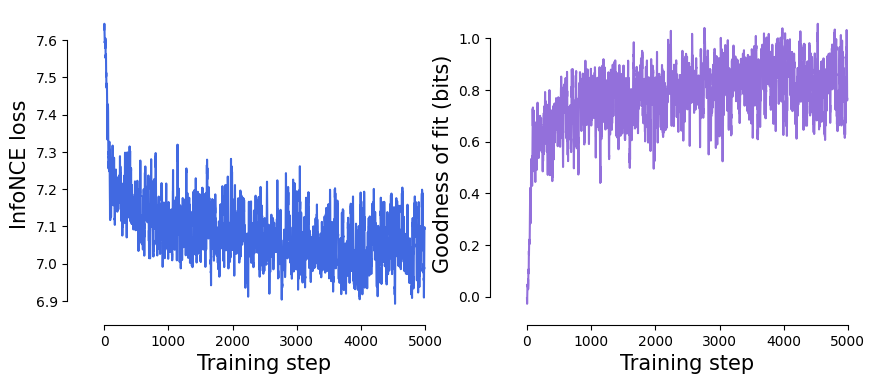

In [10]:
# We smooth the loss and goodness of fit curves for better visualization.
def smooth_curve(values, window_size=10):
    return np.convolve(values, np.ones(window_size) / window_size, mode='valid')

smoothed_loss = smooth_curve(solver.history, window_size=10)
smoothed_gof = smooth_curve(
    cebra.sklearn.metrics.infonce_to_goodness_of_fit(
        infonce=solver.history,
        batch_size=config["batch_size"],
        num_sessions=1
    ),
    window_size=10
)

# ... and plot the results
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(smoothed_loss, c="royalblue")
axes[0].set_xlabel("Training step", fontsize=15)
axes[0].set_ylabel("InfoNCE loss", fontsize=15)

axes[1].plot(smoothed_gof, c="mediumpurple")
axes[1].set_xlabel("Training step", fontsize=15)
axes[1].set_ylabel("Goodness of fit (bits)", fontsize=15)

sns.despine(
    left=False,
    right=True,
    bottom=False,
    top=True,
    trim=True,
    offset={"bottom": 5, "left": 15},
)


### Get the embeddings for each session.

In [11]:
solver = solver.to("cpu")

In [12]:
# This is similar to the multisession CEBRA-Behaviour API, but you add the labels at inference

embeddings = []
for i in range(len(train_datasets)):
    embeddings.append(solver.transform([train_datasets[j].neural.cpu() for j in range(len(train_datasets))],
                                     labels=[train_datasets[j].continuous.cpu() for j in range(len(train_datasets))], #NOTE: labels at inference
                                     session_id = i,
                                     batch_size=300).cpu().numpy())


# And we can also get the validation embeddings
val_embeddings = []
for i in range(len(train_datasets)):
    val_embeddings.append(solver.transform([valid_datasets[j].neural.cpu() for j in range(len(valid_datasets))],
                                     labels=[valid_datasets[j].continuous.cpu() for j in range(len(valid_datasets))],
                                     session_id = i,
                                     batch_size=300).cpu().numpy())

In [13]:
# And because the latent space is shared across all sessions, we can concatenate the embeddings
# into a single global embedding.

full_embedding = np.concatenate(embeddings, axis=0)
full_labels = np.concatenate([train_datasets[i].continuous_index.cpu().numpy() for i in range(len(train_datasets))], axis=0)

full_val_embedding = np.concatenate(val_embeddings, axis=0)
full_val_labels = np.concatenate([valid_datasets[i].continuous_index.cpu().numpy() for i in range(len(valid_datasets))], axis=0)

In [14]:
# Then we can plot the single-session embeddings and the global embedding.

alpha = 0.5

cols = len(embeddings) + 1
fig = make_subplots(
    rows=1,
    cols=cols,
    specs=[[{"type": "scatter3d"}, {"type": "scatter3d"}, {"type": "scatter3d"}, {"type": "scatter3d"}, {"type": "scatter3d"}]],
    subplot_titles=tuple(
        np.concatenate([np.array(
            [f"Rat {str(i+1)}" for i in range(len(embeddings))]
        ), np.array(["All rats"])])
    ),
    vertical_spacing=0,
    horizontal_spacing=0.0,
)

r_map = "magma"
l_map = "viridis"
for i in range(len(embeddings)):
    label = train_datasets[i].continuous.cpu().numpy()

    r_ind = label[:, 1] == 1
    l_ind = label[:, 2] == 1
    r_c = label[r_ind, 0]
    l_c = label[l_ind, 0]

    fig = cebra.plot_embedding_interactive(
        embeddings[i][r_ind],
        r_c,
        cmap=r_map,
        axis=fig,
        row=1,
        col=i+1,
        opacity=alpha,
        title="",
    )

    fig = cebra.plot_embedding_interactive(
        embeddings[i][l_ind],
        l_c,
        cmap=l_map,
        axis=fig,
        row=1,
        col=i+1,
        opacity=alpha,
        title="",
    )

r_ind = full_labels[:, 1] == 1
l_ind = full_labels[:, 2] == 1
r_c = full_labels[r_ind, 0]
l_c = full_labels[l_ind, 0]

fig = cebra.plot_embedding_interactive(
    full_embedding[r_ind],
    r_c,
    cmap=r_map,
    axis=fig,
    row=1,
    col=5,
    opacity=alpha,
    title="",
)

fig = cebra.plot_embedding_interactive(
    full_embedding[l_ind],
    l_c,
    cmap=l_map,
    axis=fig,
    row=1,
    col=5,
    opacity=alpha,
    title="",
)

dict_layout = dict(
        xaxis = dict(
            backgroundcolor="rgba(0, 0, 0, 0)",
            gridcolor="rgba(0, 0, 0, 0)",
            showbackground=True,
            zerolinecolor="white",
        ),
        yaxis = dict(
            backgroundcolor="rgba(0, 0, 0, 0)",
            gridcolor="rgba(0, 0, 0, 0)",
            showbackground=True,
            zerolinecolor="white",
        ),
        zaxis = dict(
            backgroundcolor="rgba(0, 0, 0, 0)",
            gridcolor="rgba(0, 0, 0, 0)",
            showbackground=True,
            zerolinecolor="white",
        ))

fig.update_layout(
    scene = dict_layout,
    scene2= dict_layout,
    scene3= dict_layout,
    scene4= dict_layout,
    scene5= dict_layout,
    width=1000,
    height=400,
)

fig.show()

## Decoding from individual latents

We show that the latents that we obtain using unified CEBRA with input masking are interpretable. We decode position and direction using the individual latents (n=32) of the global embedding.

In [15]:
def decoding_pos_dir(embedding_train, embedding_test, label_train, label_test):
    """
    Returns:
        valid r2 scores for position and direction (first), position median error (second),
        and position r2 e

    """
    pos_decoder = cebra.KNNDecoder(n_neighbors=36, metric="cosine")
    dir_decoder = cebra.KNNDecoder(n_neighbors=36, metric="cosine")

    pos_decoder.fit(embedding_train, label_train[:, 0])
    dir_decoder.fit(embedding_train, label_train[:, 1])

    pos_pred = pos_decoder.predict(embedding_test)
    dir_pred = dir_decoder.predict(embedding_test)

    prediction = np.stack([pos_pred, dir_pred], axis=1)

    pos_r2_score = sklearn.metrics.r2_score(label_test[:, 0], prediction[:, 0])
    dir_r2_score = sklearn.metrics.r2_score(label_test[:, 1], prediction[:, 1])

    return pos_r2_score, dir_r2_score

In [16]:
if os.path.exists("latent_pos_r2_score_mask.npy"):
    with open("latent_pos_r2_score_mask.npy", "rb") as f:
        latent_pos_r2 = np.load(f)
    with open("latent_dir_r2_score_mask.npy", "rb") as f:
        latent_dir_r2 = np.load(f)
else:
    latent_pos_r2, latent_dir_r2 = [], []
    for latent_i in range(full_embedding.shape[1]):
        pos_r2_score, dir_r2_score = decoding_pos_dir(full_embedding[:, latent_i][:, None], full_val_embedding[:, latent_i][:, None], full_labels, full_val_labels)
        latent_pos_r2.append(pos_r2_score)
        latent_dir_r2.append(dir_r2_score)

    with open("latent_pos_r2_score_mask.npy", "wb") as f:
        np.save(f, latent_pos_r2)

    with open("latent_dir_r2_score_mask.npy", "wb") as f:
        np.save(f, latent_dir_r2)

### $R^2$ decoding score per latent for position and direction

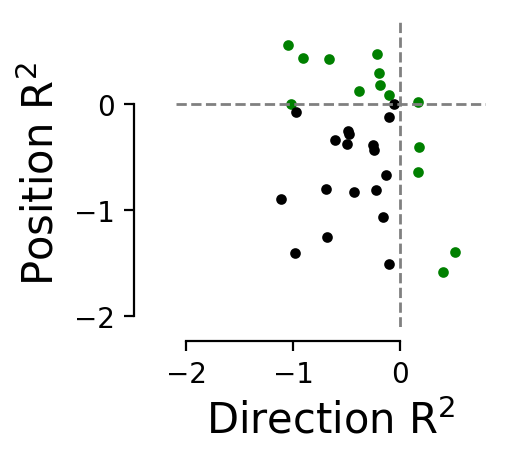

In [17]:
fig = plt.figure(figsize=(2, 2), dpi=200)
plt.scatter(latent_dir_r2[(latent_dir_r2 > 0) | (latent_pos_r2 > 0)],
            latent_pos_r2[(latent_dir_r2 > 0) | (latent_pos_r2 > 0)], s=8, color="green")
plt.scatter(latent_dir_r2[(latent_dir_r2 < 0) & (latent_pos_r2 < 0)],
            latent_pos_r2[(latent_dir_r2 < 0) & (latent_pos_r2 < 0)], s=8, color="black")
plt.xlim([-2.1, 0.8])
plt.ylim([-2.1, 0.8])

plt.hlines([0], color="grey", linestyle="--", xmin=-2.1, xmax=0.8, linewidth=1)
plt.vlines([0], color="grey", linestyle="--", ymin=-2.1, ymax=0.8, linewidth=1)

plt.ylabel("Position R$^2$", fontsize=15)
plt.xlabel("Direction R$^2$", fontsize=15)

sns.despine(
    left=False,
    right=True,
    bottom=False,
    top=True,
    trim=True,
    offset={"bottom": 5, "left": 15},
)

### Plot the best latents

We plot the best decoding latent for position and direction and compare to position trace.

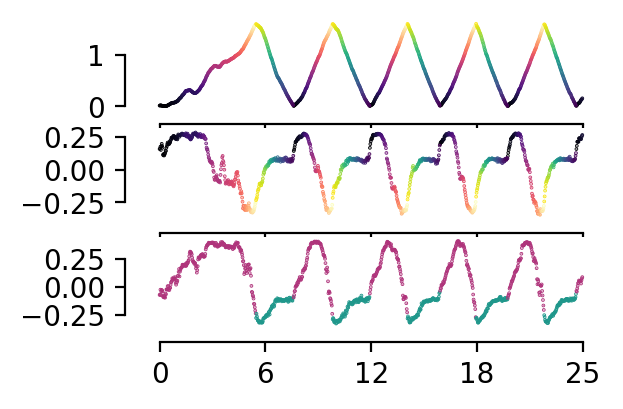

In [18]:
fig, ax = plt.subplots(3, 1, sharex=True, figsize=(3, 2), dpi=200)
n_points = 1000

labels = full_labels[:n_points, :]
embeddings_to_plot = full_embedding[:n_points, :]
r_ind = labels[:, 1] == 1
l_ind = labels[:, 2] == 1

r_c = labels[r_ind, 0]
l_c = labels[l_ind, 0]

r_cmap = "magma"
l_cmap = "viridis"

ax[0].scatter(np.arange(n_points)[r_ind], labels[r_ind,0], c=r_c, cmap = r_cmap, s=0.1)
ax[0].scatter(np.arange(n_points)[l_ind], labels[l_ind,0], c=l_c, cmap = l_cmap, s=0.1)

ax[1].scatter(np.arange(n_points)[r_ind], embeddings_to_plot[r_ind, int(np.argmax(latent_pos_r2))], c=r_c, cmap = r_cmap, s=0.1)
ax[1].scatter(np.arange(n_points)[l_ind], embeddings_to_plot[l_ind, int(np.argmax(latent_pos_r2))], c=l_c, cmap = l_cmap, s=0.1)

ax[2].scatter(np.arange(n_points), embeddings_to_plot[:, int(np.argmax(latent_dir_r2))], c=labels[:, 1], cmap = ListedColormap(["#1F978B", "#AF347B"]), s=0.1)

ax[0].set_xticks(np.linspace(0, n_points, 5), np.linspace(0, 0.025*n_points, 5, dtype = int))
ax[1].set_xticks(np.linspace(0, n_points, 5), np.linspace(0, 0.025*n_points, 5, dtype = int))
ax[2].set_xticks(np.linspace(0, n_points, 5), np.linspace(0, 0.025*n_points, 5, dtype = int))

sns.despine(
    left=False,
    right=True,
    bottom=False,
    top=True,
    trim=True,
    offset={"bottom": 5, "left": 5},
)

### ... and corresponding flow-field plot

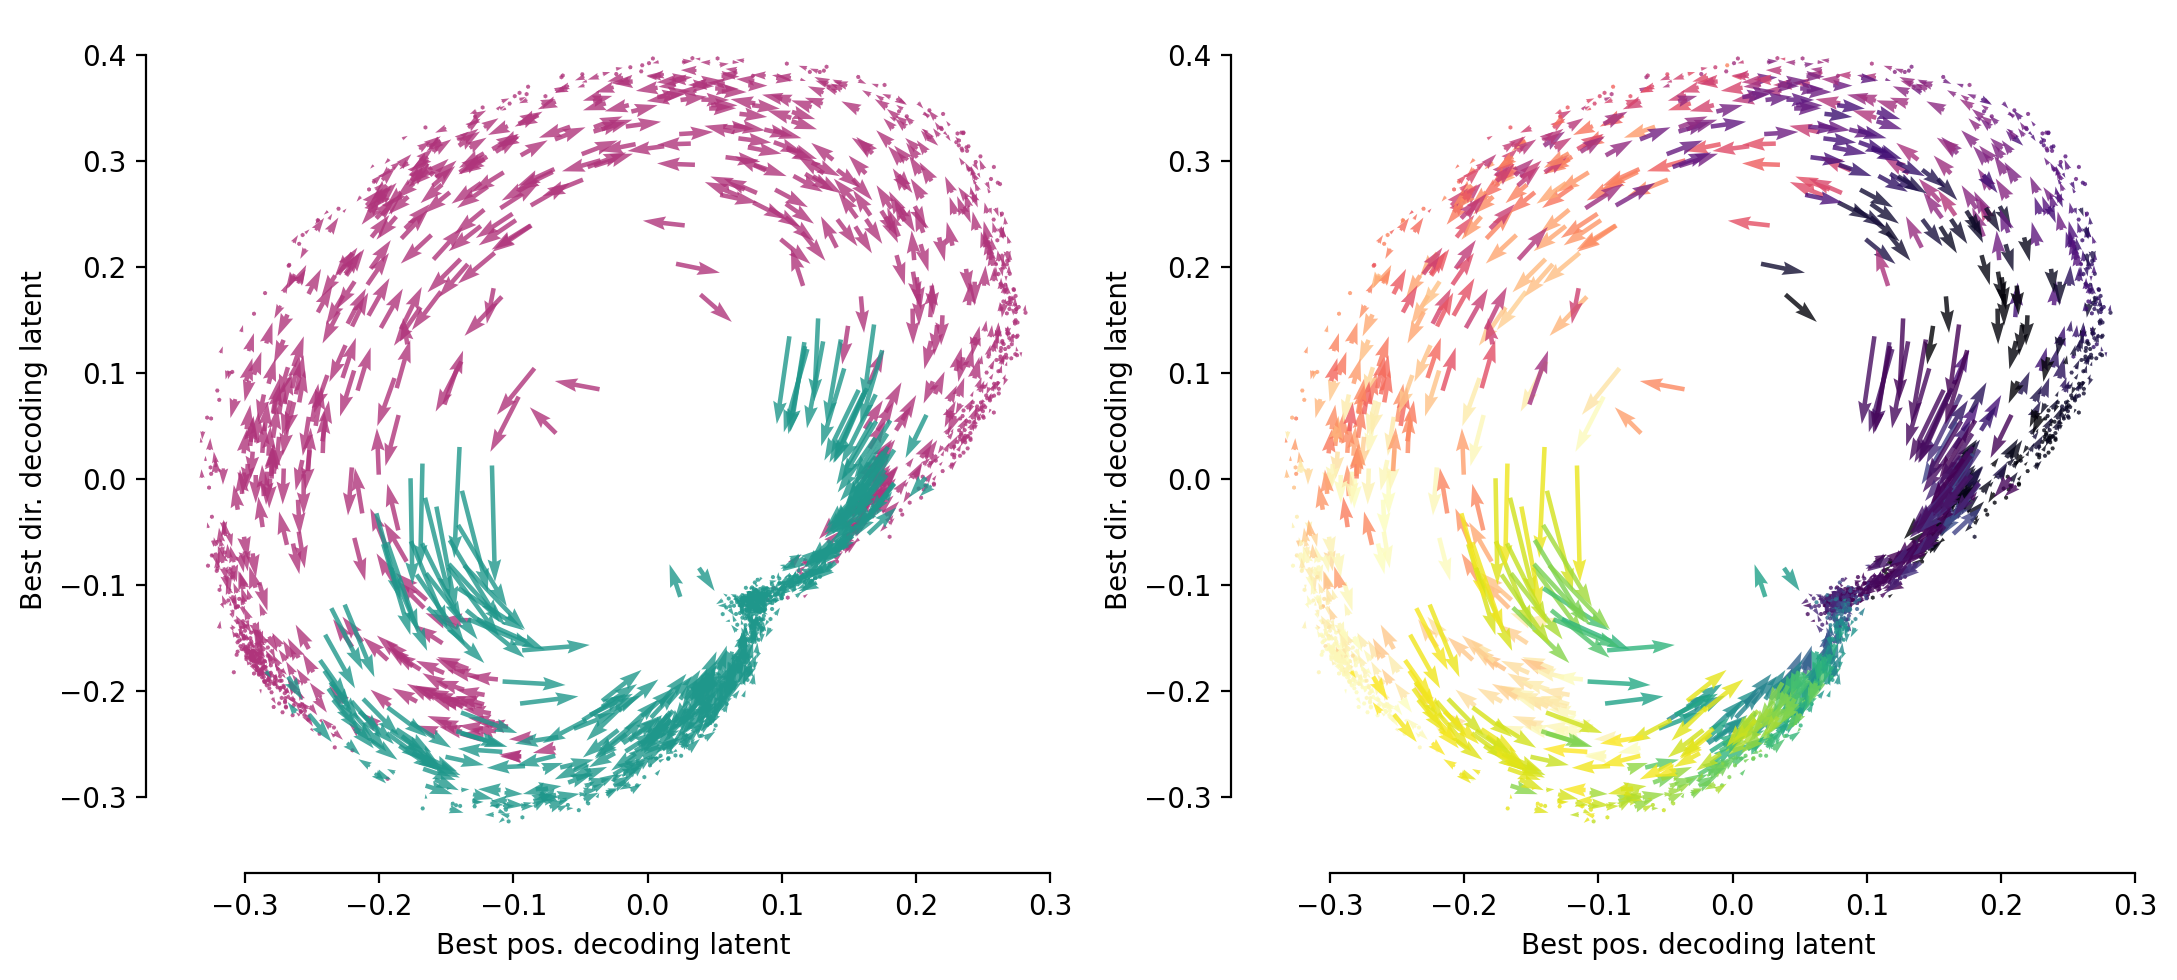

In [19]:
skip = 30

data = full_embedding[:, [int(np.argmax(latent_pos_r2)), int(np.argmax(latent_dir_r2))]][::skip, :]

dt = 0.01
velocities = np.diff(data, axis=0) / dt
positions = 0.5 * (data[:-1] + data[1:])

labels = full_labels[::skip, :][1:, :]
r_ind = labels[:, 1] == 1
l_ind = labels[:, 2] == 1

fig, ax = plt.subplots(1, 2, figsize=(11, 5), dpi=200)

ax[0].quiver(positions[r_ind, 0], positions[r_ind, 1],
           velocities[r_ind, 0], velocities[r_ind, 1], color="#AF347B", alpha=0.8, width=0.005)
ax[0].quiver(positions[l_ind, 0], positions[l_ind, 1],
           velocities[l_ind, 0], velocities[l_ind, 1], color="#1F978B", alpha=0.8, width=0.005)
ax[0].set_xlabel('Best pos. decoding latent', fontsize=10)
ax[0].set_ylabel('Best dir. decoding latent', fontsize=10)

#color_var = labels[:, 0] / dt
l_cmap = plt.cm.viridis
r_cmap = plt.cm.magma
r_c = labels[r_ind, 0] / dt
l_c = labels[l_ind, 0] / dt
norm = plt.Normalize(vmin=0/dt, vmax=1.6/dt)

ax[1].quiver(positions[r_ind, 0], positions[r_ind, 1],
           velocities[r_ind, 0], velocities[r_ind, 1], color=r_cmap(norm(r_c)), alpha=0.8, width=0.005)

ax[1].quiver(positions[l_ind, 0], positions[l_ind, 1],
           velocities[l_ind, 0], velocities[l_ind, 1], color=l_cmap(norm(l_c)), alpha=0.8, width=0.005)

ax[1].set_xlabel('Best pos. decoding latent', fontsize=10)
ax[1].set_ylabel('Best dir. decoding latent', fontsize=10)

ax[0].tick_params(axis="both", which="major", labelsize=10)
ax[1].tick_params(axis="both", which="major", labelsize=10)

sns.despine(
    left=False,
    right=True,
    bottom=False,
    top=True,
    trim=True,
    offset={"bottom": 5, "left": 5},
)

plt.tight_layout()

# Uncomplete range of behaviors

Now, let's imagine that the full range of behavior is not available in some sessions. What will their embeddings look like?

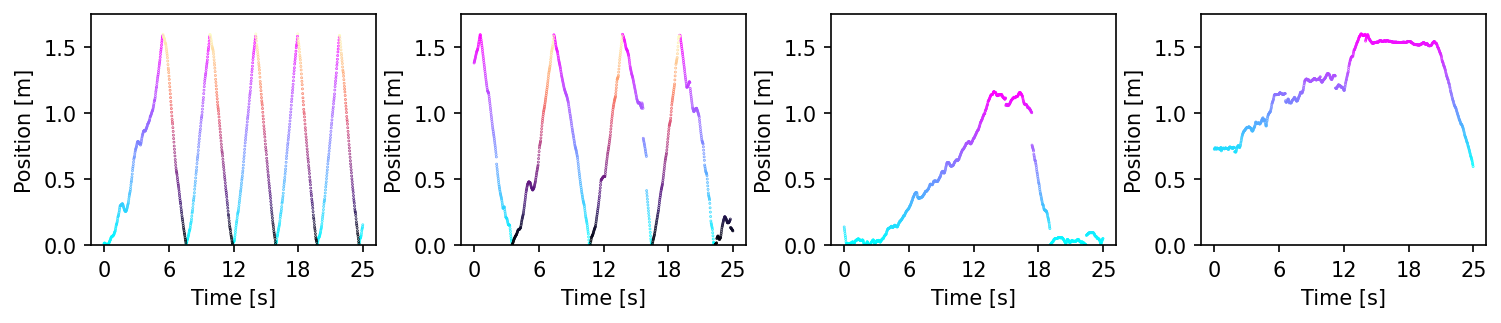

In [20]:
fig = plt.figure(figsize=(12,2), dpi=150)
plt.subplots_adjust(wspace = 0.3)

n_points = 1000 # We only select the first 1000 sample points of each dataset

for i in range(len(train_datasets)):
    ax = plt.subplot(1, 4, i+1)

    label = train_datasets[i].continuous[:n_points,:].cpu()

    r_ind = label[:, 1] == 1
    l_ind = label[:, 2] == 1

    r_cmap = "cool"
    l_cmap = "magma"
    r_c = label[r_ind, 0]
    l_c = label[l_ind, 0]

    ax.scatter(np.arange(n_points)[r_ind], label[r_ind,0], c=r_c, cmap = r_cmap, s=0.1)
    ax.scatter(np.arange(n_points)[l_ind], label[l_ind,0], c=l_c, cmap = l_cmap, s=0.1)
    ax.set_ylabel('Position [m]')
    ax.set_xlabel('Time [s]')
    ax.set_ylim([0, 1.75])
    ax.set_xticks(np.linspace(0, n_points, 5), np.linspace(0, 0.025*n_points, 5, dtype = int))
plt.show()

We can see that for Rat 3 and 4, we do not have the full range of behaviors (not to the end of the linear track).

In [21]:
# Create the 1000-samples dataset
shorter_train = train_datasets
for i in range(len(train_datasets)):
    shorter_train[i].neural = train_datasets[i].neural[:n_points,:]
    shorter_train[i].continuous = train_datasets[i].continuous[:n_points, :]

In [22]:
# Compute the embeddings, similarly to before with the same solver
embeddings = {}
for i in range(len(shorter_train)):
    embeddings[i] = solver.transform([shorter_train[j].neural for j in range(len(shorter_train))],
                                     [shorter_train[j].continuous for j in range(len(shorter_train))],
                                     session_id = i,
                                     batch_size=300).cpu().numpy()

In [23]:
markersize=2
cols = len(embeddings)
fig = make_subplots(
    rows=1,
    cols=cols,
    specs=[[{"type": "scatter3d"}, {"type": "scatter3d"}, {"type": "scatter3d"}, {"type": "scatter3d"}]],
    subplot_titles=tuple(
        np.array(
            [f"Rat {str(i+1)}" for i in range(len(embeddings))]
        )
    ),
    vertical_spacing=0,
    horizontal_spacing=0.0,
)

for i in range(len(embeddings)):
    label = shorter_train[i].continuous.cpu().numpy()

    r_ind = label[:, 1] == 1
    l_ind = label[:, 2] == 1
    r_map = "cool"
    l_map = "magma"
    r_c = label[r_ind, 0]
    l_c = label[l_ind, 0]

    fig = plot_embedding_interactive(
        embeddings[i][r_ind],
        r_c,
        cmap=r_map,
        axis=fig,
        row=1,
        col=i+1,
        opacity=alpha,
        markersize=markersize,
        title="",
    )

    fig = plot_embedding_interactive(
        embeddings[i][l_ind],
        l_c,
        cmap=l_map,
        axis=fig,
        row=1,
        col=i+1,
        opacity=alpha,
        markersize=markersize,
        title="",
    )

dict_layout = dict(
        xaxis = dict(
            backgroundcolor="rgba(0, 0, 0, 0)",
            gridcolor="rgba(0, 0, 0, 0)",
            showbackground=True,
            zerolinecolor="white",
        ),
        yaxis = dict(
            backgroundcolor="rgba(0, 0, 0, 0)",
            gridcolor="rgba(0, 0, 0, 0)",
            showbackground=True,
            zerolinecolor="white",
        ),
        zaxis = dict(
            backgroundcolor="rgba(0, 0, 0, 0)",
            gridcolor="rgba(0, 0, 0, 0)",
            showbackground=True,
            zerolinecolor="white",
        ))

fig.update_layout(
    scene = dict_layout,
    scene2= dict_layout,
    scene3= dict_layout,
    scene4= dict_layout,
    width=800,
    height=400,
)

fig.show()

We do see that the embeddings for Rat 3 and 4 are not complete but the trajectory is still very clear (because it was trained on the full range of behaviors).

But now, can we get a common embedding visualization? Yes, because the embeddings are infered from the latent space we can just consider all of them all together (concatenation in time).

In [24]:
# Assemble all behaviors together.
embeddings = []
for i in range(len(shorter_train)):
    embeddings.append(solver.transform([shorter_train[j].neural for j in range(len(shorter_train))],
                                     [shorter_train[j].continuous for j in range(len(shorter_train))], #NOTE: labels at inference
                                     session_id = i,
                                     batch_size=300).cpu().numpy())
embeddings = np.concatenate(embeddings)

In [25]:

fig = make_subplots(
    rows=1,
    cols=1,
    specs=[[{"type": "scatter3d"}]],
    vertical_spacing=0,
    horizontal_spacing=0.0,
)

# We concatenate the behaviors as well
label = [shorter_train[i].continuous.cpu().numpy() for i in range(len(shorter_train))]
label = np.concatenate(label)

r_ind = label[:, 1] == 1
l_ind = label[:, 2] == 1
r_map = "cool"
l_map = "magma"
r_c = label[r_ind, 0]
l_c = label[l_ind, 0]

fig = plot_embedding_interactive(
    embeddings[r_ind],
    r_c,
    cmap=r_map,
    axis=fig,
    row=1,
    col=1,
    opacity=alpha,
    markersize=markersize,
    title="",
)

fig = plot_embedding_interactive(
    embeddings[l_ind],
    l_c,
    cmap=l_map,
    axis=fig,
    row=1,
    col=1,
    markersize=markersize,
    opacity=alpha,
    title="",
)

dict_layout = dict(
        xaxis = dict(
            backgroundcolor="rgba(0, 0, 0, 0)",
            gridcolor="rgba(0, 0, 0, 0)",
            showbackground=True,
            zerolinecolor="white",
        ),
        yaxis = dict(
            backgroundcolor="rgba(0, 0, 0, 0)",
            gridcolor="rgba(0, 0, 0, 0)",
            showbackground=True,
            zerolinecolor="white",
        ),
        zaxis = dict(
            backgroundcolor="rgba(0, 0, 0, 0)",
            gridcolor="rgba(0, 0, 0, 0)",
            showbackground=True,
            zerolinecolor="white",
        ))

fig.update_layout(
    scene = dict_layout,
    width=600,
    height=600,
)

fig.show()